In [1]:
import pandas as pd 
import numpy as np 

from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_digits, fetch_california_housing

# Clasificación
iris = load_iris(as_frame=True).frame
wine = load_wine(as_frame=True).frame
cancer = load_breast_cancer(as_frame=True).frame
digits = load_digits(as_frame=True).frame

# Regresión
california = fetch_california_housing(as_frame=True).frame

<h3>Boosting</h3>
<p>El boosting es un metodo utilizado en el machine learning para reducir errores. El boosting crea un modelo de conjunto mediante la combinacion secuencial de varios arboles de decision <b>debiles</b>. es decir ser mejor que dejar una decision al azar. Este asigna ponderaciones a las salidas de los arboles individuales, luego, a las clasificaciones incorrectas del primer arboles de decisiojn les da una poderacion alta y una entrada al arbol siguiente. Despues de numerosos ciclos, el metodo boosting combina estas reglas debiles en una unica regla de prediccion poderosa.</p>

<h3>Bagging</h3>
<p>Tambien conocido como bootstrapping, es el metodo de aprendizaje por conujuntos que se emplea comunmente para reducir la varianza dentro de un conjunto de datos ruidoso.</p>
<p>En el bagging se selecciona una muestra aleatorea de datos, esto quiere decir que algunos puntos de datos individuales se pueden elegir mas de una vez. Despues de generar varias muestras de datos, estos modelos debiles se entrenan de manera indipendiente.Dependiendo de la tarea, el promedio o la mayoria de esas predicciones arrojan una estimacion mas precisa.</p>
<img src="https://towardsdatascience.com/wp-content/uploads/2021/01/1zTgGBTQIMlASWm5QuS2UpA.jpeg"/>



In [6]:
# Utilizando bagging con el datasets de iris 
iris.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


In [2]:
# separar datos en features y target 
X = iris.drop(['target'],axis=1)
y = iris['target']

# importar libreria para generar split de entrenamiento y test 
from sklearn.model_selection import train_test_split

# separar datos en entrenamiento y testeo 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# importar e implementar modelo 
from sklearn.ensemble import RandomForestClassifier

# Parámetros fundamentales
# n_estimators: El número de árboles de decisión que componen el bosque. Un mayor número generalmente mejora la precisión pero aumenta el tiempo de entrenamiento. 
# max_depth: La profundidad máxima que puede alcanzar cada árbol. Controla la complejidad del modelo. 
# min_samples_split: El número mínimo de muestras que se requieren para que un nodo interno se divida en dos. 
# min_samples_leaf: El número mínimo de muestras que debe haber en una hoja terminal del árbol. 
# max_features: El número de características que se consideran en cada división. Esto ayuda a que los árboles sean más diversos. 

# modelos con sus parametros 
model = RandomForestClassifier(max_depth=3,
                              n_estimators=3,
                              min_samples_split=10,
                              min_samples_leaf=10,
                              max_features=1)

# entrenar y revisar resultados
model.fit(X_train,y_train)
y_hat_test = model.predict(X_test)
y_hat_train = model.predict(X_train)

# revisar resultados 
from sklearn.metrics import accuracy_score


accuracy_test = accuracy_score(y_hat_test,y_test)
accuracy_train = accuracy_score(y_hat_train,y_train)

print(f"accuracy test : {accuracy_test}, accuracy train : {accuracy_train}")


# revisar como la produndidad de mi modelo tambien afectar al resultado 
depths = [1,2,3,4,5,6,7,8,9,10]
resultados = []

for depth in depths:
    model = RandomForestClassifier(max_depth=depth,random_state=42).fit(X_train,y_train)
    y_hat = model.predict(X_test)
    accuracy = accuracy_score(y_hat,y_test)
    resultados.append(accuracy)

resultados


accuracy test : 1.0, accuracy train : 0.9666666666666667


[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

<p><b>comentarios</b>: podemos ver que al aplicar hiperparametros al modelo podemos reducir la probabilidad de que nuestro modelo genere un overfiting, ya que el modelo sin hiperparametros genera arboles mas profundos y ajustandose a los datos de entrenamiento. </p>

<h3>random forest es solo un ensamble entren muchos tipos</h3>
<p>Como sabemos random forest es parte de bagging, este busca ensamblar multiples modelos, donde la baja correlacion entre ellos permite mejorar el rendimiento. SI el ensamble de estos modelos se hace ultizando otro clasificador se conoce como stacking.</p>
<p>Una manera distinta de hacer ensambles es intentar que exista una correlacion explicita entren los modelos, pero enfocada en la reduccion del error. los cuales boosting, los cuales veremos a continuacion.</p>

<h3>Boosting</h3>

<p>Como ya habiamos visto antes el boosting va agregando modelos progresivamentes debiles, en donde cada uno busca el mejor rendimiento actual del ensamble. El mecanismo de boosting mas utilizado es el descenso del gradiente.</p>

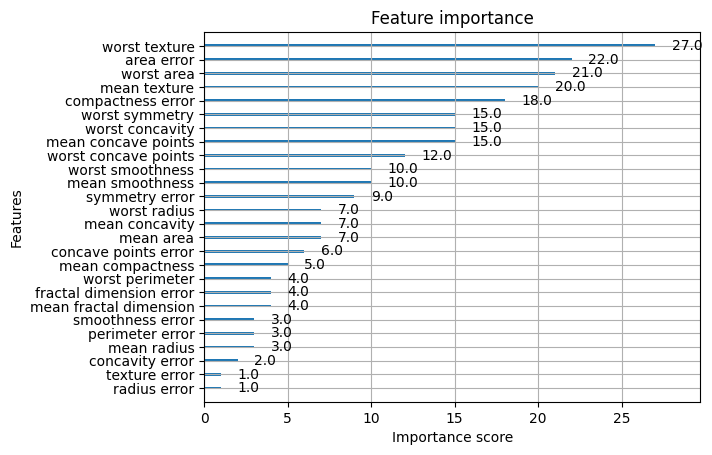

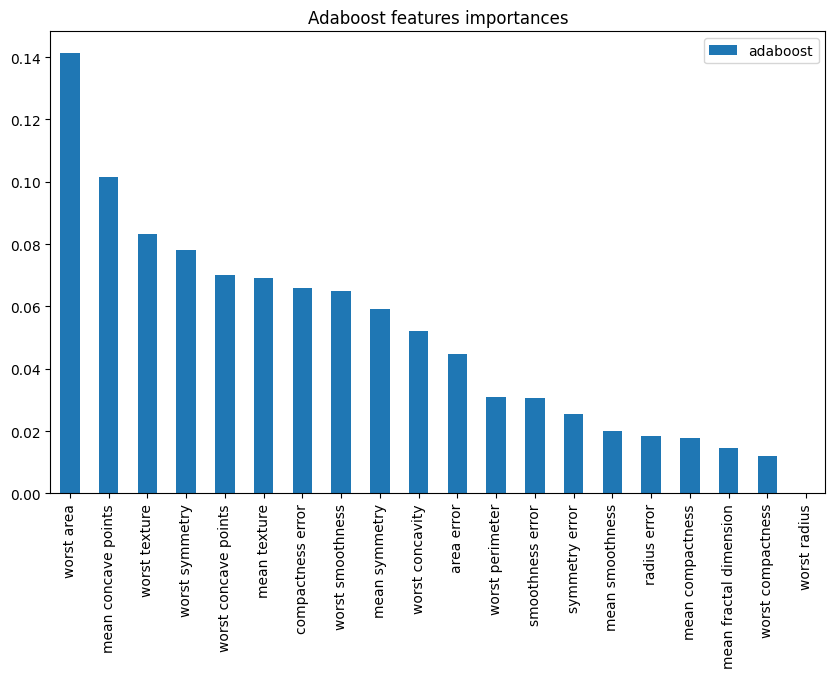

xtgboost result :0.956140350877193
adaboost result : 0.9649122807017544


In [42]:
# Cancer dataset (Adaboost, Xgboost, lightGBM) 
import matplotlib.pyplot as plt

# separar variables 
X,y = cancer.drop(['target'],axis=1), cancer.target

# separar datos en entrenamiento y testeo
# importar modelos 
def xgboost_model(train_x, train_y):
    from xgboost import XGBClassifier
    from xgboost import plot_importance

    model = XGBClassifier().fit(train_x, train_y)
    # resultado importancias
    plot_importance(model)
    plt.show()
    
    return model

def adaboost_model(x_train, train_y):
    from sklearn.ensemble import AdaBoostClassifier

    model = AdaBoostClassifier().fit(x_train,train_y)    
    
    df_import = pd.DataFrame({
        'adaboost' : model.feature_importances_
    },index=x_train.columns)

    # ordenar 
    df_import = df_import.sort_values(by="adaboost",ascending=False)

    # plotear
    df_import.head(20).plot(kind='bar',figsize=(10,6))
    plt.title("Adaboost features importances")
    plt.show()
    
    return model


# funcion para validar modelos
def accuracy_models(x_validate,y_test, model):
    from sklearn.metrics import accuracy_score
    # (prediccion, test)
    return accuracy_score(model.predict(x_validate), y_test)


def main_train():
    
    # 1.separar variables 
    X,y = cancer.drop(['target'],axis=1), cancer.target
    
    # 2.separar datos en entrenamiento y testeo 
    X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

    # 3. entrenar y validar modelos 
    xgb = xgboost_model(X_train,y_train)
    adaboost = adaboost_model(X_train, y_train)

    # 4. generar predicciones y resultados 

    # revisar resultados 
    accuracy_xgb = accuracy_models(X_test,y_test,xgb)
    accuracy_ada = accuracy_models(X_test, y_test, adaboost)
    print(f"xtgboost result :{accuracy_xgb}")
    print(f"adaboost result : {accuracy_ada}")

    # 5. plotear la importancia de variables 


main_train()